In [145]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
from math import factorial as ft 
import plotly.express as px
plt.style.use('ggplot')

In [146]:
df_survey = pd.read_csv('/Users/leahdeyoung/Desktop/GitHub/re_new_repos/the-bronfman-fellowship/2025_Campus_Commons_Program_Evaluation-2025-05-09-12-18-38.csv', encoding = "utf-8")


In [147]:
display(df_survey.sample(10))

,Application ID,Application Title,Applicant First Name,Applicant Last Name,Applicant Email Address,Applicant System ID,Program Name,"Campus Commons fellows are encouraged to participate in a research partnership between The Bronfman Fellowship and CASJE (Collaborative for Applied Studies in Jewish Education) at The George Washington University. Study participants will fill out a short form and participate in one or two interviews, with an opportunity to earn up to $100. The study will explore Jewish undergraduate bridge-builders’ experiences on campus, and how Jewish identity relates to bridge-building work. The study will be conducted by Dr. Elana Riback Rand, a post-doctoral research fellow at CASJE. You can email Elana at elana.rand@gwu.edu for any questions.This study is completely separate from your Campus Commons fellowship. You are under no obligation to participate in the study. Please indicate whether you are interested in learning more about this project.","""Post-Program Evaluation"" completion status","""Post-Program Evaluation"" completion date/time",...,"Were there any topics or perspectives you felt hesitant to express during Campus Commons? If so, what contributed to this hesitation? If not, what helped create an environment where you felt comfortable sharing your views?","After participating in Campus Commons, how likely are you to… | Engage in additional bridge building opportunities","After participating in Campus Commons, how likely are you to… | Seek out Jewish community","After participating in Campus Commons, how likely are you to… | Participate in the Campus Commons alumni network and programming","After participating in Campus Commons, how likely are you to… | Stay connected with Campus Commons staff team & faculty","After participating in Campus Commons, how likely are you to… | Stay connected with members of my Campus Commons cohort",Would you recommend Campus Commons to someone else?,Please elaborate on your answer to the previous question.,The Zoom model is still something that we’re adjusting. What is one thing you enjoyed about the experience and one thing that was difficult about the experience?,"Thank you for taking time to complete this survey! If you have any questions or want to share anything else, please add it here:"
8,2024--7633111648,Ariel Kohn,Ari,Kohn,akohn@college.harvard.edu,127082519,Campus Commons Application Spring 2025,"Yes, I am interested in learning more about th...",Completed,2025-04-28 20:13:12-04:00,...,None...,Very likely,Very likely,Very likely,Very likely,Very likely,Yes,I think that so many of my Jewish friends woul...,I enjoyed the ease of joining from my campus a...,NaN
24,2024--1687661812,Elisheva Feintuch,Elisheva,Feintuch,elisheva.feintuch@yale.edu,129004637,Campus Commons Application Spring 2025,NaN,Not started,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,2024--4644785327,Henry Karpovas Lisak,Henry,Karpovas Lisak,karpo016@umn.edu,128939548,Campus Commons Application Spring 2025,"Yes, I am interested in learning more about th...",Completed,2025-04-28 20:11:46-04:00,...,I don’t think so. Since this is such a diverse...,Very likely,Very likely,Very likely,Very likely,Very likely,Yes,NaN,I don’t think the zoom session added a lot to ...,NaN
21,2024--6324540581,Danielle Tsvilikhovskaya,Danielle,Tsvilikhovskaya,dtsvilik@depaul.edu,128973589,Campus Commons Application Spring 2025,"No, I am not interested in learning more about...",Completed,2025-04-28 20:19:30-04:00,...,I was initially scared to express my views on ...,Very likely,Very likely,Very likely,Very likely,Very likely,Yes,Its a great opportunity to expand your boarder...,Zoom doesnt have the same level of connectivit...,NaN
31,2024--1528667459,2024--1528667459,Noah,Kassis,noah.kassis@gmail.com,129219944,Campus Commons Application Spring 2025,"Yes, I am interested in learning more about th...",Completed,2025-04-28 20:12:32-04:00,...,No,Somewhat likely,Very likely,Very likely,Very likely,Very likely,Yes,"O

In [148]:
df_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 63 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          Non-Null Count  Dtype  
---  ------         

In [149]:
columns_to_drop = ['Application ID', 'Application Title', 'Applicant Email Address', 'Applicant System ID', 'Program Name', '"Post-Program Evaluation" completion status', '"Post-Program Evaluation" completion date/time']

In [150]:
df_survey = df_survey.drop(columns_to_drop, axis=1)
df_survey = df_survey.drop(df_survey.columns[2], axis=1)
df_survey = df_survey.drop(11)
df_survey = df_survey.drop(24)
df_survey = df_survey.drop(0)

In [151]:
df_survey[df_survey.columns[54]] = df_survey[df_survey.columns[54]].fillna('None').astype(str)
df_survey[df_survey.columns[53]] = df_survey[df_survey.columns[53]].fillna('None').astype(str)
df_survey[df_survey.columns[52]] = df_survey[df_survey.columns[52]].fillna('None').astype(str)
df_survey[df_survey.columns[45]] = df_survey[df_survey.columns[45]].fillna('None').astype(str)
df_survey[df_survey.columns[32]] = df_survey[df_survey.columns[32]].fillna('None').astype(str)
df_survey[df_survey.columns[33]] = df_survey[df_survey.columns[33]].fillna('None').astype(str)

In [152]:
display(df_survey.sample(10))

,Applicant First Name,Applicant Last Name,What is your graduation year? [other],Which Jewish campus organizations are you a part of? (Select all that apply),Which Jewish campus organizations are you a part of?,What are your plans for this summer? Please be as specific as possible.,"For the following, please indicate your participation and if you found the experience to be valuable: | Being at Isabella Freedman for the retreat","For the following, please indicate your participation and if you found the experience to be valuable: | Homegroup experience","For the following, please indicate your participation and if you found the experience to be valuable: | Dialogue Labs","For the following, please indicate your participation and if you found the experience to be valuable: | Engaging with Jewish texts (Shiur)",...,"Were there any topics or perspectives you felt hesitant to express during Campus Commons? If so, what contributed to this hesitation? If not, what helped create an environment where you felt comfortable sharing your views?","After participating in Campus Commons, how likely are you to… | Engage in additional bridge building opportunities","After participating in Campus Commons, how likely are you to… | Seek out Jewish community","After participating in Campus Commons, how likely are you to… | Participate in the Campus Commons alumni network and programming","After participating in Campus Commons, how likely are you to… | Stay connected with Campus Commons staff team & faculty","After participating in Campus Commons, how likely are you to… | Stay connected with members of my Campus Commons cohort",Would you recommend Campus Commons to someone else?,Please elaborate on your answer to the previous question.,The Zoom model is still something that we’re adjusting. What is one thing you enjoyed about the experience and one thing that was difficult about the experience?,"Thank you for taking time to complete this survey! If you have any questions or want to share anything else, please add it here:"
5,Julian,Brenman,2025.0,None of the above,None of the above,Looking for full time work since I’m graduating!!,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,...,None,Very likely,Very likely,Very likely,Very likely,Very likely,Yes,It was so good for me so I want others to grow...,I loved bthe reminders to keep in touch - the ...,"I love everything I learned , you guys really ..."
22,Talia,Holzman,2027.0,Hillel,"Hillel,Chabad,Non-Hillel Jewish community orga...",Governmental relations and advocacy intern at ...,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,...,No not really,Very likely,Very likely,Very likely,Somewhat likely,Very likely,Yes,I have to other students in Claremont (Emilio ...,"I enjoyed seeing everyone again, I wish homegr...",None
13,Grayson,Kaufman,2027.0,Hillel,Hillel,Working as a pharmacy technician,I participated and found it valuable,I participated but did NOT find it valuable,Did not attend,I participated but did NOT find it valuable,...,"Yes, I still felt judged by some individuals f...",Somewhat likely,Somewhat likely,Not likely,Not likely,Somewhat likely,No,I did not find this fellowship beneficial to m...,I am neutral re this topic.,None
7,Maddy,Hefner,2026.0,Choice 2Chabad,"Chabad,StandWithUs","Volunteering in Israel, seminary and interning",I participated and found it valuable,I participated and found it valuable,I participated but did NOT find it valuable,I participated but did NOT find it valuable,...,I think the calming environment where we were ...,Somewhat likely,Very likely,Very likely,Somewhat likely,Somewhat likely,Yes,None,Breakout rooms were fun but sitting and listen...,None
2,Haylie,Keller,2026.0,Non-Hillel Jewish community organization on c...,"Hillel,Chabad,Students Supporting Israel (SSI)",Goi

In [153]:
df_survey.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 1 to 31
Data columns (total 55 columns):
 #   Column                                                                                                                                                                                                                                         Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                                                         --------------  -----  
 0   Applicant First Name                                                                                                                                                                                                                           29 non-null     object 
 1   Applicant Last Name                                                                          

In [223]:
print(df_survey['Which Jewish campus organizations are you a part of? (Select all that apply)'].values)

['Hillel' ' Non-Hillel Jewish community organization on campus' 'Hillel'
 ' Non-Hillel Jewish community organization on campus' 'None of the above'
 'Hillel' 'Chabad' 'Hillel' 'Hillel' 'Hillel' 'Hillel' 'Hillel' 'Hillel'
 'None of the above' 'AJC Campus' 'Hillel' 'Hillel' 'Hillel' 'Hillel'
 ' Other' 'Hillel' 'Hillel' 'Hillel' 'Hillel' 'Hillel' 'Hillel' 'Hillel'
 'Students Supporting Israel (SSI)' 'Hillel']


In [222]:
#df_survey['Which Jewish campus organizations are you a part of? (Select all that apply)'].contains('Choice 2Chabad'):
df_survey['Which Jewish campus organizations are you a part of? (Select all that apply)'] = df_survey['Which Jewish campus organizations are you a part of? (Select all that apply)'].replace({'Choice 2Chabad': 'Chabad'})

In [154]:
df_survey = df_survey.rename(columns={'For the following, please indicate your participation and if you found the experience to be valuable:  | Being at Isabella Freedman for the retreat': 'Being at Isabella Freedman for the retreat', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Homegroup experience': 'Homegroup experience', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Dialogue Labs': 'Dialogue Labs', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Engaging with Jewish texts (Shiur)': 'Engaging with Jewish texts (Shiur)', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Skills-Based Social Psychology Sessions': 'Skills-Based Social Psychology Sessions', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Middot & Music sessions with Arielle Korman': 'Middot & Music sessions with Arielle Korman'})

In [155]:
df_survey = df_survey.rename(columns={'How frequently do you plan to apply Campus Commons approaches and learnings in the following contexts? | Jewish Spaces ON campus (e.g., Hillel, Chabad, Jewish-related clubs)?': 'Jewish Spaces ON campus (e.g., Hillel, Chabad, Jewish-related clubs)', 'How frequently do you plan to apply Campus Commons approaches and learnings in the following contexts? | Jewish Spaces OFF campus (e.g., synagogue, community building, camp, etc.)':'Jewish Spaces OFF campus (e.g., synagogue, community building, camp, etc.)', 'How frequently do you plan to apply Campus Commons approaches and learnings in the following contexts? | Secular/Non-Jewish spaces ON campus (e.g., student clubs, campus work, peer mentorship, etc.)?': 'Secular/Non-Jewish spaces ON campus (e.g., student clubs, campus work, peer mentorship, etc.)', 'How frequently do you plan to apply Campus Commons approaches and learnings in the following contexts? | Secular/Non-Jewish spaces OFF campus (e.g., personal relationships, workplaces, etc.)?': 'Secular/Non-Jewish spaces OFF campus (e.g., personal relationships, workplaces, etc.)?'})

In [156]:
df_survey = df_survey.rename(columns={'Please rate the importance of these aspects of Campus Commons to your experience: | Informal discussions with other cohort participants ': 'Informal discussions with other cohort participants', 'Please rate the importance of these aspects of Campus Commons to your experience: | Building a network of peers with diverse perspectives': 'Building a network of peers with diverse perspectives', 'Please rate the importance of these aspects of Campus Commons to your experience: | Being part of a pluralistic Jewish community': 'Being part of a pluralistic Jewish community', 'Please rate the importance of these aspects of Campus Commons to your experience: | Campus Commons staff mentorship and support': 'Campus Commons staff mentorship and support', 'Please rate the importance of these aspects of Campus Commons to your experience: | Support with my Implementation Project': 'Support with my Implementation Project'})

In [157]:
df_survey = df_survey.rename(columns={'After participating in Campus Commons I… | Appreciate doing Jewish text study with a diverse group of Jews': 'Appreciate doing Jewish text study with a diverse group of Jews', 'After participating in Campus Commons I… | Believe that my voice matters in interpreting Jewish text': 'Believe that my voice matters in interpreting Jewish text', 'After participating in Campus Commons I… | Think Jewish text study can help me explore my Jewish identity' : 'Think Jewish text study can help me explore my Jewish identity', 'After participating in Campus Commons I… | Have increased pride or connection to my Jewish identity': 'Have increased pride or connection to my Jewish identity', 'After participating in Campus Commons I… | Want to participate in more Jewish learning and programming': 'Want to participate in more Jewish learning and programming', 'After participating in Campus Commons I… | Have a wider diversity of Jewish friends': 'Have a wider diversity of Jewish friends', 'After participating in Campus Commons I… | Have a wider diversity of Jewish mentors, teachers, and role models ' : 'Have a wider diversity of Jewish mentors, teachers, and role models', 'After participating in Campus Commons I… | Believe bringing Jews of diverse backgrounds/beliefs together is important': 'Believe bringing Jews of diverse backgrounds/beliefs together is important'})

In [158]:
df_survey = df_survey.rename(columns={'After Participating in Campus Commons, how likely are you to… | Seek out conversations with people whose perspectives differ from my own': 'Seek out conversations with people whose perspectives differ from my own', 'After Participating in Campus Commons, how likely are you to… | Question my own assumptions and beliefs': 'Question my own assumptions and beliefs', 'After Participating in Campus Commons, how likely are you to… | Hold different perspectives at once, even when they seem contradictory': 'Hold different perspectives at once, even when they seem contradictory', 'After Participating in Campus Commons, how likely are you to… | Encourage others to engage with diverse perspectives and communities': 'Encourage others to engage with diverse perspectives and communities', 'After Participating in Campus Commons, how likely are you to… | Hold my own values, convictions, and identity within difficult conversation': 'Hold my own values, convictions, and identity within difficult conversation', 'After Participating in Campus Commons, how likely are you to… | Establish relationships with people holding  perspectives contradictory to my own': 'Establish relationships with people holding  perspectives contradictory to my own'})

In [159]:
df_survey = df_survey.rename(columns={'After participating in Campus Commons, I am better able to: | Ask questions that lead to deeper understanding of others’ viewpoints': 'Ask questions that lead to deeper understanding of others’ viewpoints', 'After participating in Campus Commons, I am better able to: | Listen to perspectives that challenge my own ': 'Listen to perspectives that challenge my own', 'After participating in Campus Commons, I am better able to: | Identify and manage my emotional responses in challenging conversations': 'Identify and manage my emotional responses in challenging conversations', 'After participating in Campus Commons, I am better able to: | Articulate important aspects of my own identity and values': 'Articulate important aspects of my own identity and values', 'After participating in Campus Commons, I am better able to: | Access information about Jewish programs and opportunities': 'Access information about Jewish programs and opportunities'})

In [160]:
df_survey = df_survey.rename(columns={'After participating in Campus Commons, how likely are you to… | Engage in additional bridge building opportunities': 'Engage in additional bridge building opportunities', 'After participating in Campus Commons, how likely are you to… | Seek out Jewish community': 'Seek out Jewish community', 'After participating in Campus Commons, how likely are you to… | Participate in the Campus Commons alumni network and programming': 'Participate in the Campus Commons alumni network and programming', 'After participating in Campus Commons, how likely are you to… | Stay connected with Campus Commons  staff team & faculty': 'Stay connected with Campus Commons  staff team & faculty', 'After participating in Campus Commons, how likely are you to… | Stay connected with members of my Campus Commons cohort ': 'Stay connected with members of my Campus Commons cohort'})

In [161]:
df_survey.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 1 to 31
Data columns (total 55 columns):
 #   Column                                                                                                                                                                                                                                         Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                                                         --------------  -----  
 0   Applicant First Name                                                                                                                                                                                                                           29 non-null     object 
 1   Applicant Last Name                                                                          

In [162]:
value_columns = [
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Being at Isabella Freedman for the retreat',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Homegroup experience',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Dialogue Labs',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Engaging with Jewish texts (Shiur)',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Skills-Based Social Psychology Sessions',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Middot & Music sessions with Arielle Korman'
]

value_column_rename = [
    'Being at Isabella Freedman for the retreat',
    'Homegroup experience',
    'Dialogue Labs',
    'Engaging with Jewish texts (Shiur)',
    'Skills-Based Social Psychology Sessions',
    'Middot & Music sessions with Arielle Korman'
]

In [163]:
importance_rename = [
    'Informal discussions with other cohort participants',
    'Building a network of peers with diverse perspectives',
    'Being part of a pluralistic Jewish community',
    'Campus Commons staff mentorship and support',
    'Support with my Implementation Project'
]     

In [164]:
context_rename = [
    'Jewish Spaces ON campus (e.g., Hillel, Chabad, Jewish-related clubs)',
    'Jewish Spaces OFF campus (e.g., synagogue, community building, camp, etc.)',
    'Secular/Non-Jewish spaces ON campus (e.g., student clubs, campus work, peer mentorship, etc.)',
    'Secular/Non-Jewish spaces OFF campus (e.g., personal relationships, workplaces, etc.)?'
]   



In [165]:
participating_rename = [
    'Believe that my voice matters in interpreting Jewish text',
    'Think Jewish text study can help me explore my Jewish identity',
    'Have increased pride or connection to my Jewish identity',
    'Have a wider diversity of Jewish friends',
    'Have a wider diversity of Jewish mentors, teachers, and role models',
    'Believe bringing Jews of diverse backgrounds/beliefs together is important'
]



In [166]:
ability_rename = [
    'Seek out conversations with people whose perspectives differ from my own',
    'Question my own assumptions and beliefs',
    'Hold different perspectives at once, even when they seem contradictory',
    'Encourage others to engage with diverse perspectives and communities',
    'Hold my own values, convictions, and identity within difficult conversation',
    'Establish relationships with people holding  perspectives contradictory to my own'
]


In [167]:
perspective_rename = [
    "Ask questions that lead to deeper understanding of others’ viewpoints",
    'Listen to perspectives that challenge my own',
    'Identify and manage my emotional responses in challenging conversations',
    'Articulate important aspects of my own identity and values',
    'Access information about Jewish programs and opportunities'
]

 

In [168]:
engagement_rename = [
    'Engage in additional bridge building opportunities',
    'Seek out Jewish community',
    'Participate in the Campus Commons alumni network and programming',
    'Stay connected with Campus Commons  staff team & faculty',
    'Stay connected with members of my Campus Commons cohort',
]

 

In [169]:
df_value = pd.concat([
    df_survey[col].value_counts(dropna=False).rename(col)
    for col in df_survey[value_column_rename]  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [170]:
df_importance = pd.concat([
    df_survey[col].value_counts(dropna=False).rename(col)
    for col in df_survey[importance_rename]  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [171]:
df_context = pd.concat([
    df_survey[col].value_counts(dropna=False).rename(col)
    for col in df_survey[context_rename]  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [172]:
df_participate = pd.concat([
    df_survey[col].value_counts(dropna=False).rename(col)
    for col in df_survey[participating_rename]  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [173]:
df_ability = pd.concat([
    df_survey[col].value_counts(dropna=False).rename(col)
    for col in df_survey[ability_rename]  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [174]:
df_perspective = pd.concat([
    df_survey[col].value_counts(dropna=False).rename(col)
    for col in df_survey[perspective_rename]  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [175]:
df_engagement = pd.concat([
    df_survey[col].value_counts(dropna=False).rename(col)
    for col in df_survey[engagement_rename]  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [176]:
df_recommend = pd.concat([
    df_survey['Would you recommend Campus Commons to someone else?'].value_counts(dropna=False).rename('Would you recommend Campus Commons to someone else?')
    #for col in df_survey['Would you recommend Campus Commons to someone else? ']  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [177]:

df_bridge_build = pd.concat([
    df_survey['As a result of your Campus Commons experience, approximately how many people have you engaged in bridge-building conversations, pluralistic activities, or other applications of what you learned? '].value_counts(dropna=False).rename('As a result of your Campus Commons experience, approximately how many people have you engaged in bridge-building conversations, pluralistic activities, or other applications of what you learned?')
    #for col in df_survey['Would you recommend Campus Commons to someone else? ']  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [178]:
display(df_value)
display(df_importance)
display(df_context)
display(df_participate)
display(df_ability)
display(df_perspective)
display(df_engagement)

,I participated and found it valuable,I participated but did NOT find it valuable,Did not attend,I don’t remember
Being at Isabella Freedman for the retreat,29,0,0,0
Homegroup experience,27,2,0,0
Dialogue Labs,24,4,1,0
Engaging with Jewish texts (Shiur),21,7,0,1
Skills-Based Social Psychology Sessions,17,9,0,3
Middot & Music sessions with Arielle Korman,14,10,4,1


,Very important,Somewhat important,Not important,I don’t remember
Informal discussions with other cohort participants,28,1,0,0
Building a network of peers with diverse perspectives,24,5,0,0
Being part of a pluralistic Jewish community,22,6,1,0
Campus Commons staff mentorship and support,19,7,3,0
Support with my Implementation Project,5,9,10,5


,Sometimes,Often,Never
"Jewish Spaces ON campus (e.g., Hillel, Chabad, Jewish-related clubs)",15,13,1
"Jewish Spaces OFF campus (e.g., synagogue, community building, camp, etc.)",18,9,2
"Secular/Non-Jewish spaces ON campus (e.g., student clubs, campus work, peer mentorship, etc.)",17,9,3
"Secular/Non-Jewish spaces OFF campus (e.g., personal relationships, workplaces, etc.)?",15,12,2


,To the same extent,To a greater extent,To a lesser extent
Believe that my voice matters in interpreting Jewish text,14,14,1
Think Jewish text study can help me explore my Jewish identity,11,17,1
Have increased pride or connection to my Jewish identity,15,14,0
Have a wider diversity of Jewish friends,6,23,0
"Have a wider diversity of Jewish mentors, teachers, and role models",8,21,0
Believe bringing Jews of diverse backgrounds/beliefs together is important,9,20,0


,Very likely,Somewhat likely
Seek out conversations with people whose perspectives differ from my own,21,8
Question my own assumptions and beliefs,25,4
"Hold different perspectives at once, even when they seem contradictory",24,5
Encourage others to engage with diverse perspectives and communities,26,3
"Hold my own values, convictions, and identity within difficult conversation",26,3
Establish relationships with people holding perspectives contradictory to my own,22,7


,Greatly improved,Somewhat improved,Not improved
Ask questions that lead to deeper understanding of others’ viewpoints,13,13,3
Listen to perspectives that challenge my own,16,11,2
Identify and manage my emotional responses in challenging conversations,13,11,5
Articulate important aspects of my own identity and values,13,14,2
Access information about Jewish programs and opportunities,15,12,2


,Very likely,Somewhat likely,Not likely
Engage in additional bridge building opportunities,18,11,0
Seek out Jewish community,25,4,0
Participate in the Campus Commons alumni network and programming,20,7,2
Stay connected with Campus Commons staff team & faculty,18,8,3
Stay connected with members of my Campus Commons cohort,23,5,1


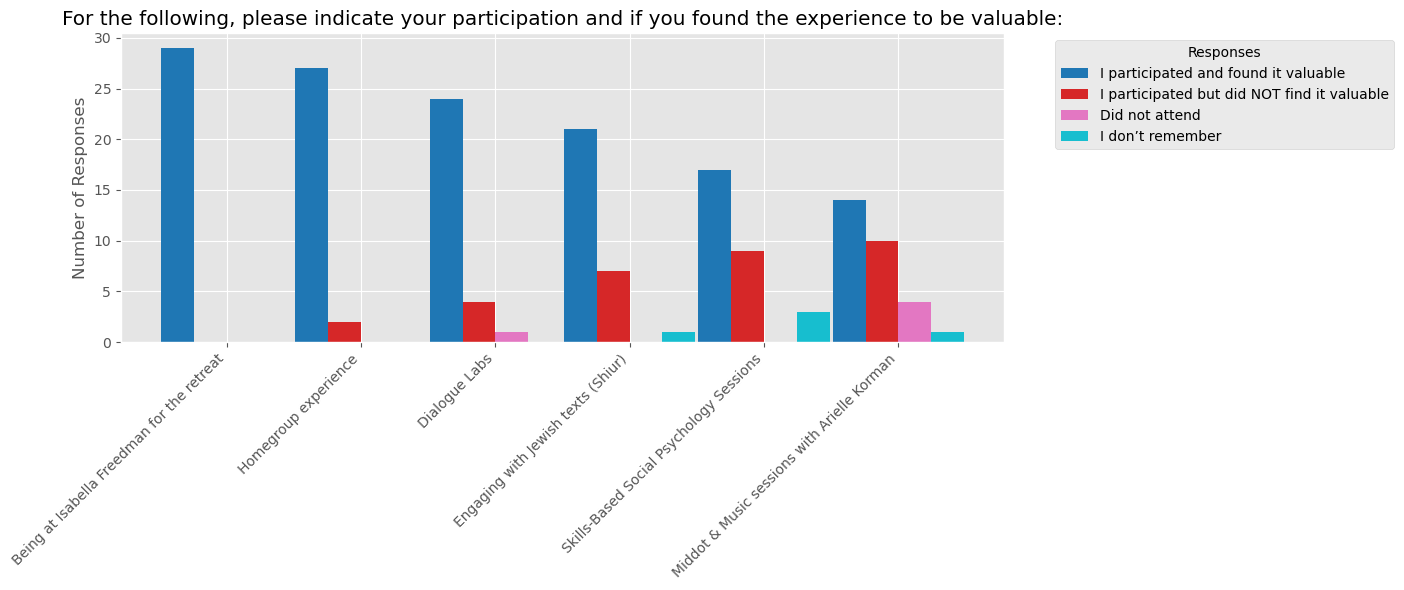

In [227]:


# Add labels and title
n_groups = len(df_value)
n_bars = len(df_value.columns)  # number of unique responses
bar_width = 2
gap = 0.2  # space between groups

# X locations for groups
indices = np.arange(n_groups) * (n_bars * bar_width + gap)
colors = plt.get_cmap('tab10')(np.linspace(0, 1, n_bars))

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each response type
bars=[]
for i, response in enumerate(df_value.columns):
    x = indices + i * bar_width
    bar = ax.bar(x, df_value[response], width=bar_width, label=response, color=colors[i])
    bars.append(bar)  # Add each bar container to the list

# Ticks and labels
ax.set_xticks(indices + (n_bars * bar_width) / 2 - bar_width / 2)
ax.set_xticklabels(df_value.index, rotation=45, ha='right')

#ax.set_xlabel('Experience')
ax.set_ylabel('Number of Responses')
ax.set_title('For the following, please indicate your participation and if you found the experience to be valuable:')
ax.legend(handles=[bar for bar in bars], title='Responses', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

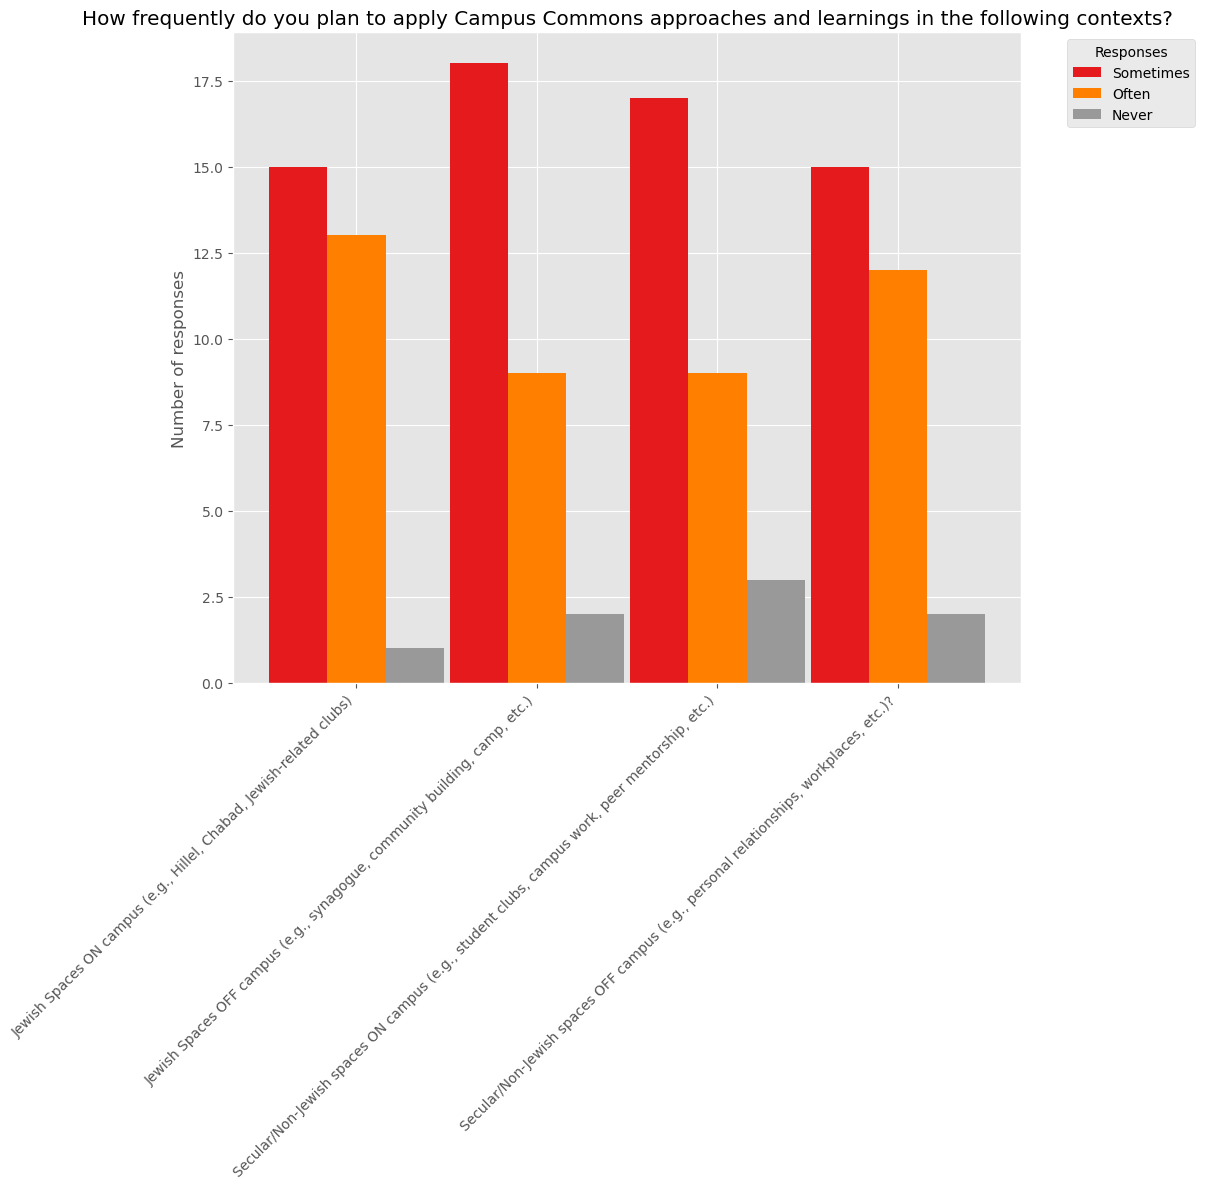

In [226]:
# Add labels and title
n_groups = len(df_context)
n_bars = len(df_context.columns)  # number of unique responses
bar_width = 2
gap = 0.2  # space between groups

# X locations for groups
indices = np.arange(n_groups) * (n_bars * bar_width + gap)
colors = plt.get_cmap('Set1')(np.linspace(0, 1, n_bars))

# Create the plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot each response type
bars=[]
for i, response in enumerate(df_context.columns):
    x = indices + i * bar_width
    bar = ax.bar(x, df_context[response], width=bar_width, label=response, color=colors[i])
    bars.append(bar)  # Add each bar container to the list

# Ticks and labels
ax.set_xticks(indices + (n_bars * bar_width) / 2 - bar_width / 2)
ax.set_xticklabels(df_context.index, rotation=45, ha='right')

#ax.set_ylim(10)
#ax.set_xlabel('Number of responses')
ax.set_ylabel('Number of responses')
ax.set_title('How frequently do you plan to apply Campus Commons approaches and learnings in the following contexts?')
ax.legend(handles=[bar for bar in bars], title='Responses', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

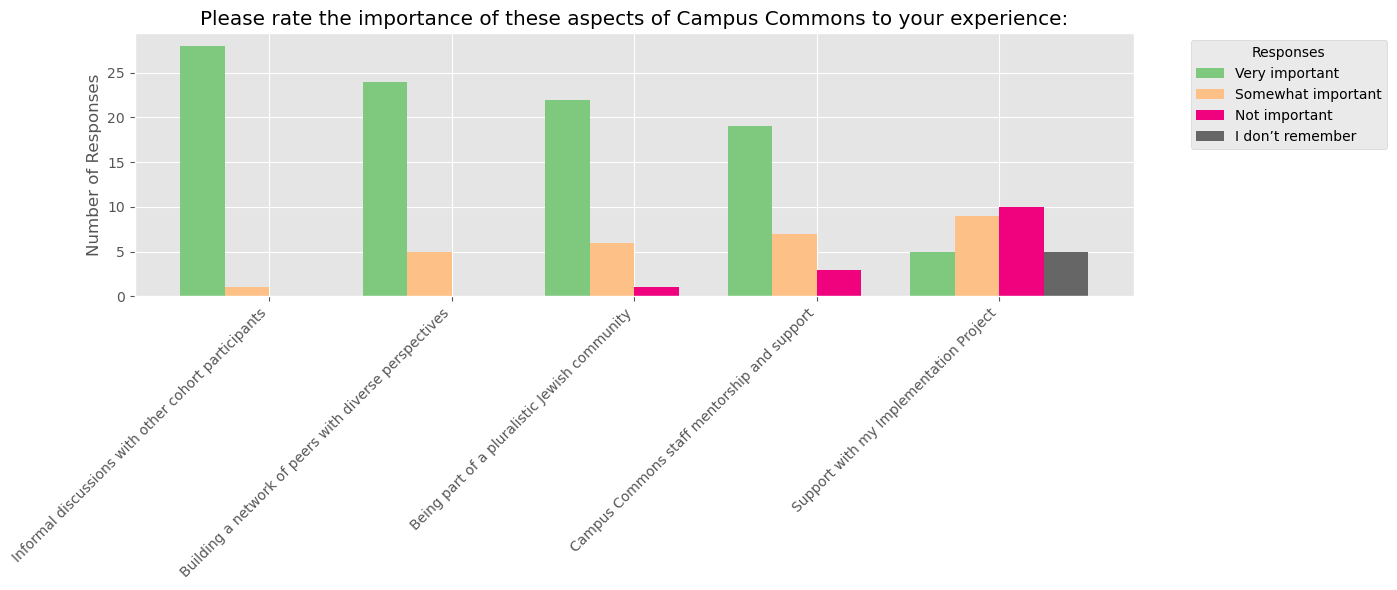

In [225]:
# Add labels and title
n_groups = len(df_importance)
n_bars = len(df_importance.columns)  # number of unique responses
bar_width = 2
gap = 0.2  # space between groups

# X locations for groups
indices = np.arange(n_groups) * (n_bars * bar_width + gap)
colors = plt.get_cmap('Accent')(np.linspace(0, 1, n_bars))

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each response type
bars=[]
for i, response in enumerate(df_importance.columns):
    x = indices + i * bar_width
    bar = ax.bar(x, df_importance[response], width=bar_width, label=response, color=colors[i])
    bars.append(bar)  # Add each bar container to the list

# Ticks and labels
ax.set_xticks(indices + (n_bars * bar_width) / 2 - bar_width / 2)
ax.set_xticklabels(df_importance.index, rotation=45, ha='right')

#ax.set_ylim(10)
#ax.set_xlabel('Aspect of Campus Commons')
ax.set_ylabel('Number of Responses')
ax.set_title('Please rate the importance of these aspects of Campus Commons to your experience:')
ax.legend(handles=[bar for bar in bars], title='Responses', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

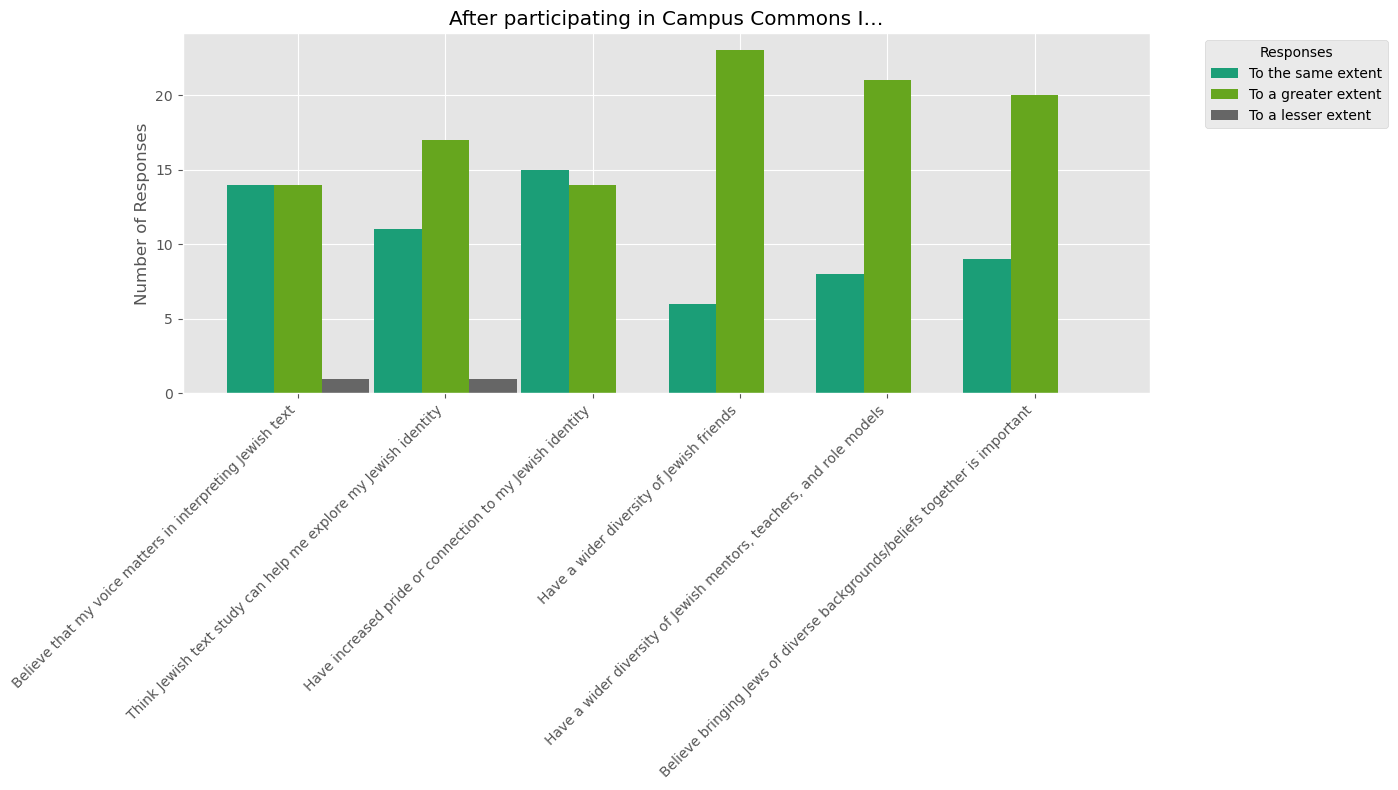

In [228]:
# Add labels and title
n_groups = len(df_participate)
n_bars = len(df_participate.columns)  # number of unique responses
bar_width = 2
gap = 0.2  # space between groups

# X locations for groups
indices = np.arange(n_groups) * (n_bars * bar_width + gap)
colors = plt.get_cmap('Dark2')(np.linspace(0, 1, n_bars))

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot each response type
bars=[]
for i, response in enumerate(df_participate.columns):
    x = indices + i * bar_width
    bar = ax.bar(x, df_participate[response], width=bar_width, label=response, color=colors[i])
    bars.append(bar)  # Add each bar container to the list

# Ticks and labels
ax.set_xticks(indices + (n_bars * bar_width) / 2 - bar_width / 2)
ax.set_xticklabels(df_participate.index, rotation=45, ha='right')

#ax.set_ylim(10)
#ax.set_xlabel('Belief')
ax.set_ylabel('Number of Responses')
ax.set_title('After participating in Campus Commons I…')
ax.legend(handles=[bar for bar in bars], title='Responses', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

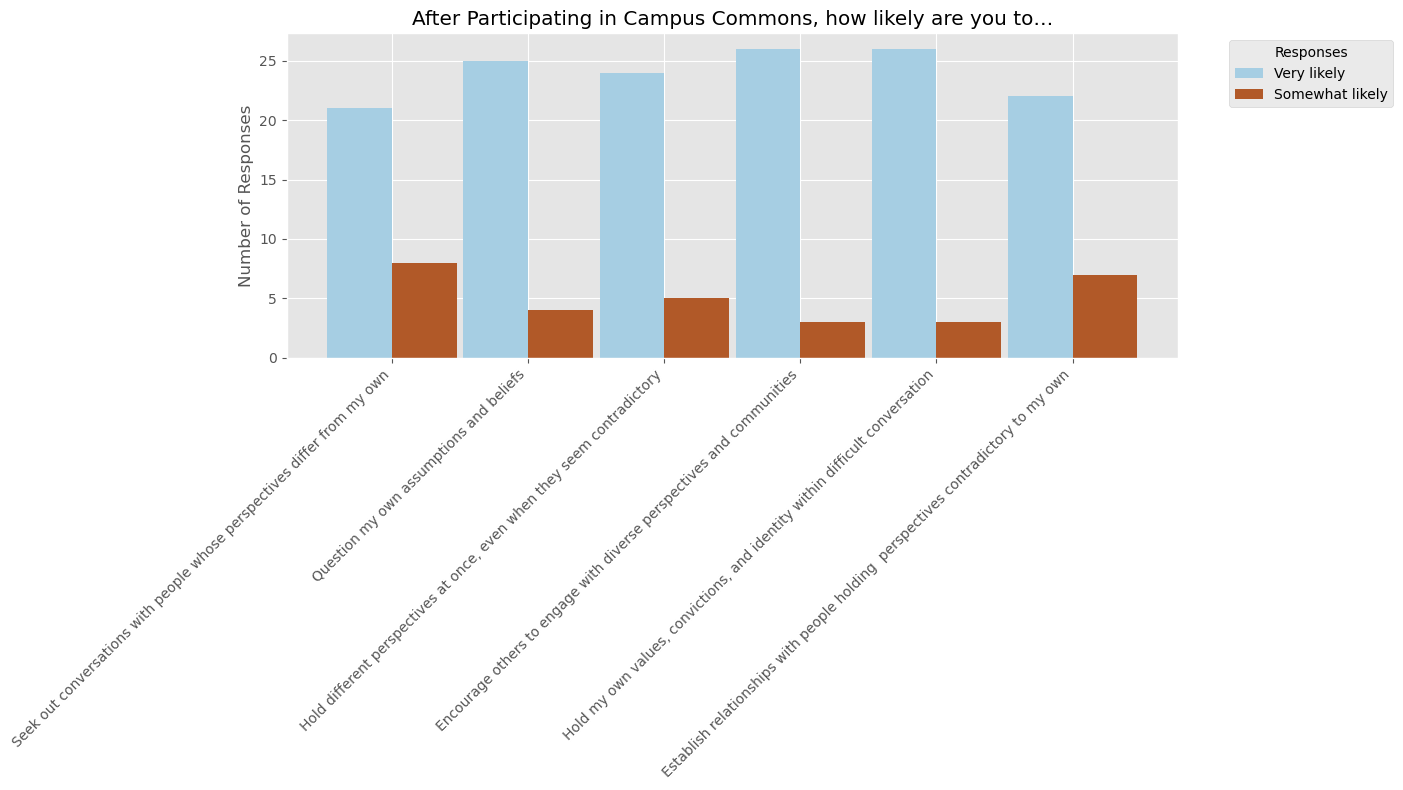

In [229]:
# Add labels and title
n_groups = len(df_ability)
n_bars = len(df_ability.columns)  # number of unique responses
bar_width = 2
gap = 0.2  # space between groups

# X locations for groups
indices = np.arange(n_groups) * (n_bars * bar_width + gap)
colors = plt.get_cmap('Paired')(np.linspace(0, 1, n_bars))

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot each response type
bars=[]
for i, response in enumerate(df_ability.columns):
    x = indices + i * bar_width
    bar = ax.bar(x, df_ability[response], width=bar_width, label=response, color=colors[i])
    bars.append(bar)  # Add each bar container to the list


# Ticks and labels
ax.set_xticks(indices + (n_bars * bar_width) / 2 - bar_width / 2)
ax.set_xticklabels(df_ability.index, rotation=45, ha='right')

#ax.set_ylim(10)
#ax.set_xlabel('Belief')
ax.set_ylabel('Number of Responses')
ax.set_title('After Participating in Campus Commons, how likely are you to…')
ax.legend(handles=[bar for bar in bars], title='Responses', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

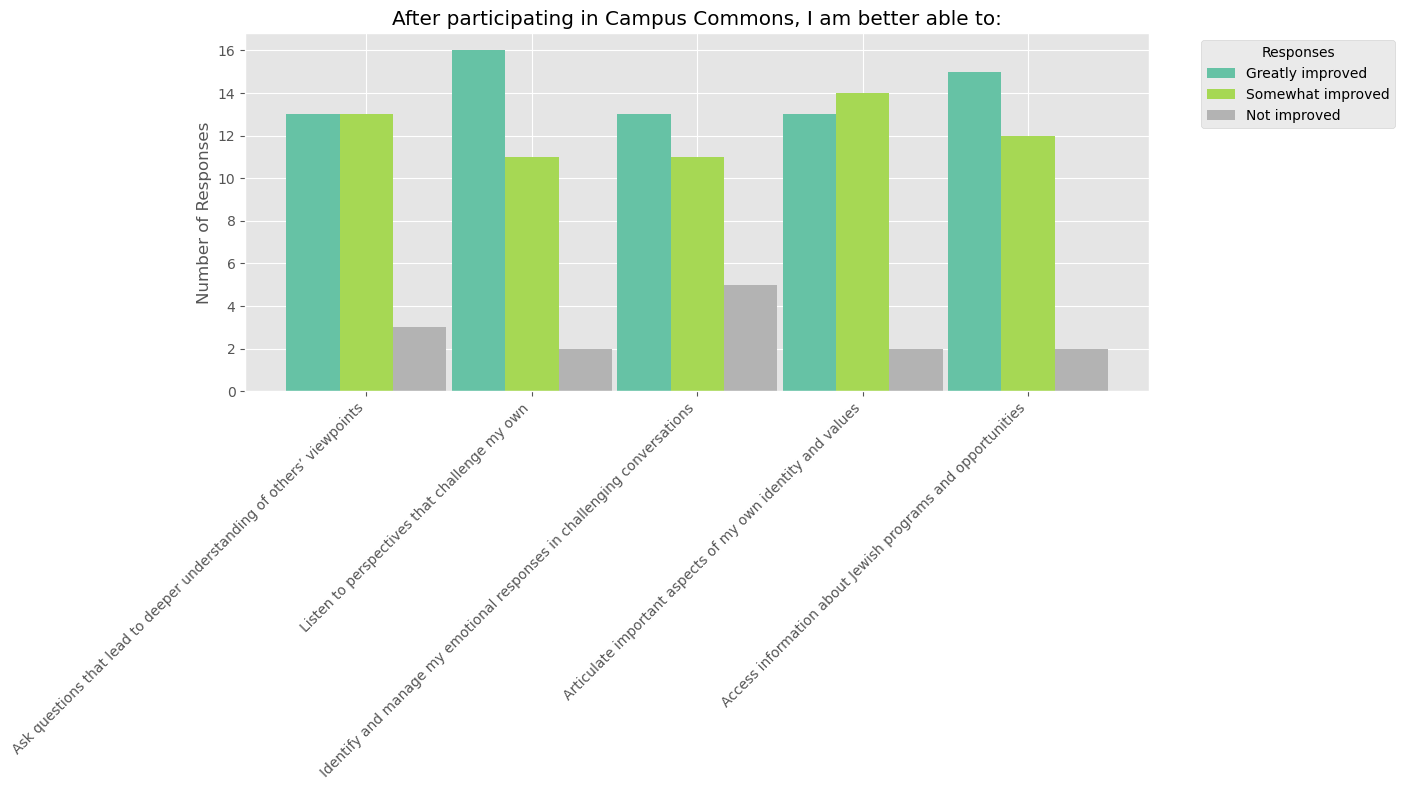

In [230]:
# Add labels and title
n_groups = len(df_perspective)
n_bars = len(df_perspective.columns)  # number of unique responses
bar_width = 2
gap = 0.2  # space between groups

# X locations for groups
indices = np.arange(n_groups) * (n_bars * bar_width + gap)
colors = plt.get_cmap('Set2')(np.linspace(0, 1, n_bars))

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot each response type
bars = [] 
for i, response in enumerate(df_perspective.columns):
    x = indices + i * bar_width
    bar = ax.bar(x, df_perspective[response], width=bar_width, label=response, color=colors[i])
    bars.append(bar)  # Add each bar container to the list

# Ticks and labels
ax.set_xticks(indices + (n_bars * bar_width) / 2 - bar_width / 2)
ax.set_xticklabels(df_perspective.index, rotation=45, ha='right')

#ax.set_ylim(10)
#ax.set_xlabel('Action to take')
ax.set_ylabel('Number of Responses')
ax.set_title('After participating in Campus Commons, I am better able to:')
ax.legend(handles=[bar for bar in bars], title='Responses', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

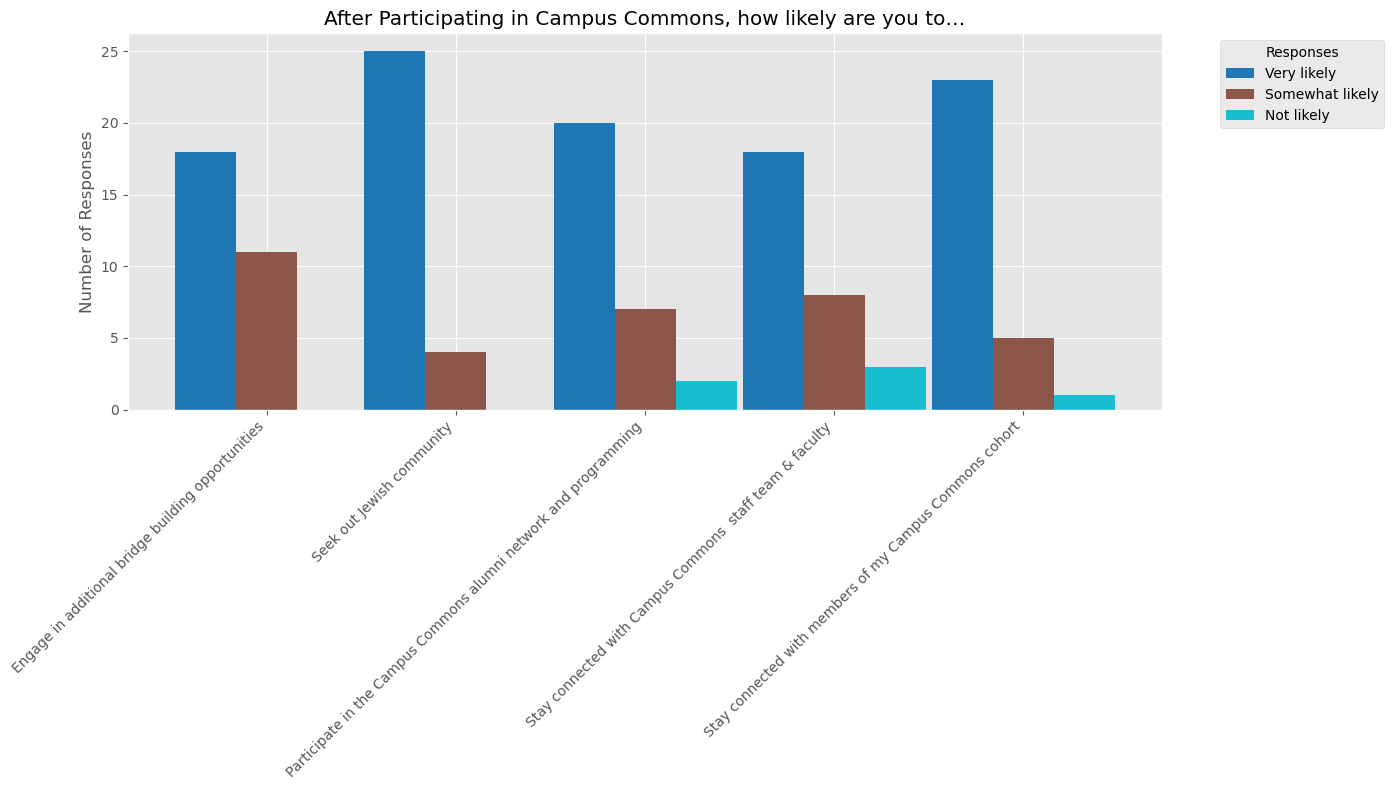

In [231]:
# Add labels and title
n_groups = len(df_engagement)
n_bars = len(df_engagement.columns)  # number of unique responses
bar_width = 2
gap = 0.2  # space between groups

# X locations for groups
indices = np.arange(n_groups) * (n_bars * bar_width + gap)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.get_cmap('tab10')(np.linspace(0, 1, n_bars))

# Plot each response type

bars = []  
for i, response in enumerate(df_engagement.columns):
    x = indices + i * bar_width
    bar = ax.bar(x, df_engagement[response], width=bar_width, label=response, color=colors[i])
    bars.append(bar)  # Add each bar container to the list

    
for i, response in enumerate(df_engagement.columns):
    x = indices + i * bar_width
    ax.bar(x, df_engagement[response], width=bar_width, label=response, color=colors[i])

# Ticks and labels
ax.set_xticks(indices + (n_bars * bar_width) / 2 - bar_width / 2)
ax.set_xticklabels(df_engagement.index, rotation=45, ha='right')

#ax.set_ylim(10)
#ax.set_xlabel('Action Taken')
ax.set_ylabel('Number of Responses')
ax.set_title('After Participating in Campus Commons, how likely are you to…')
ax.legend(handles=[bar for bar in bars], title='Responses', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [186]:
display(df_recommend)

Would you recommend Campus Commons to someone else?,Yes,No
Would you recommend Campus Commons to someone else?,27,2


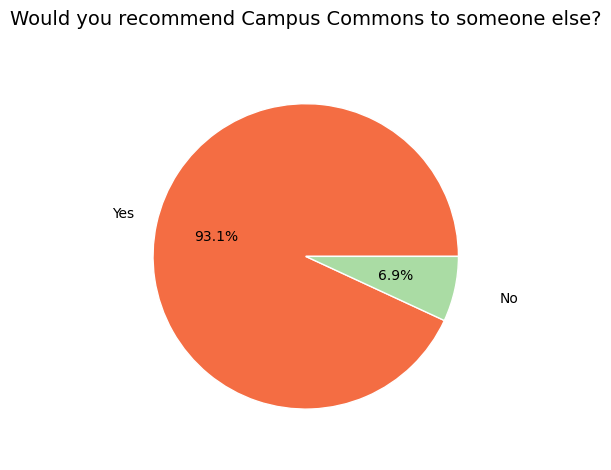

In [187]:
# Select the row you want to plot
row = df_recommend.iloc[0]  # or use .loc['row_label'] if you have a named index

# Extract labels and values
labels = row.index          # Column names become labels
values = row.values         # Row values become pie sizes

# Generate color map
colors = plt.get_cmap('Spectral')(np.linspace(0.2, 0.7, len(row)))

# Plot pie chart
fig, ax = plt.subplots()
ax.pie(values,
       labels=labels,
       colors=colors,
       radius=3,
       center=(4, 4),
       autopct='%1.1f%%',
       labeldistance=1.3,
       wedgeprops={"linewidth": 1, "edgecolor": "white"})

# Set limits to make sure it's nicely placed
ax.set(xlim=(0, 8), 
       ylim=(0, 8))

ax.set_title("Would you recommend Campus Commons to someone else?", fontsize=14, pad=20)

plt.tight_layout()
plt.show()

In [188]:
display(df_bridge_build)

"As a result of your Campus Commons experience, approximately how many people have you engaged in bridge-building conversations, pluralistic activities, or other applications of what you learned?",1-10 people,11-25 people,26-50 people,None yet,51-100 people,More than 100 people
"As a result of your Campus Commons experience, approximately how many people have you engaged in bridge-building conversations, pluralistic activities, or other applications of what you learned?",13,7,5,2,1,1


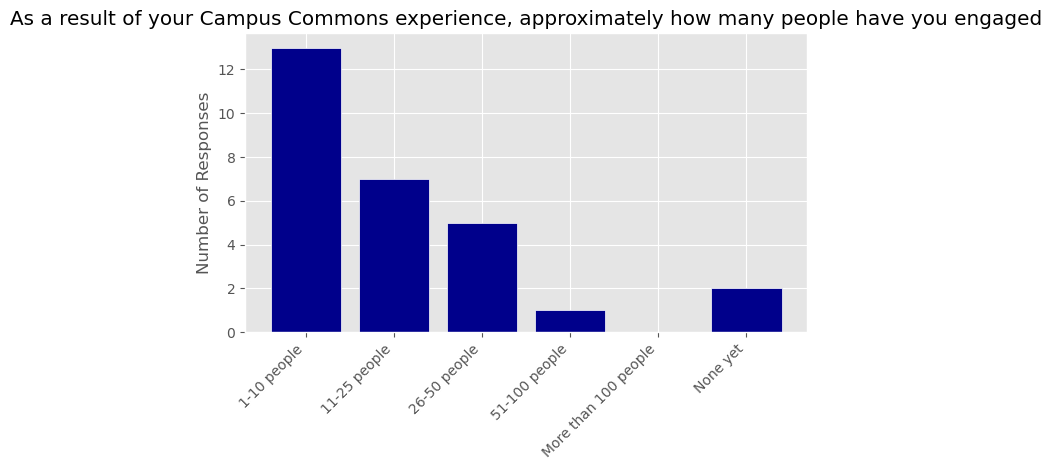

In [232]:
data = {
    'Category': ['1-10 people', '11-25 people', '26-50 people', '51-100 people', 'More than 100 people', 'None yet'],
    'Count': [13, 7, 5, 1, 0, 2]
}

df_bridge_build = pd.DataFrame(data)

fig, ax = plt.subplots()

ax.bar(df_bridge_build['Category'], df_bridge_build['Count'], color='darkblue', edgecolor='white')

# Set title and labels
ax.set_title("As a result of your Campus Commons experience, approximately how many people have you engaged")
#ax.set_xlabel("Number of People")
ax.set_ylabel("Number of Responses")

# Rotate x labels if needed for better display
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

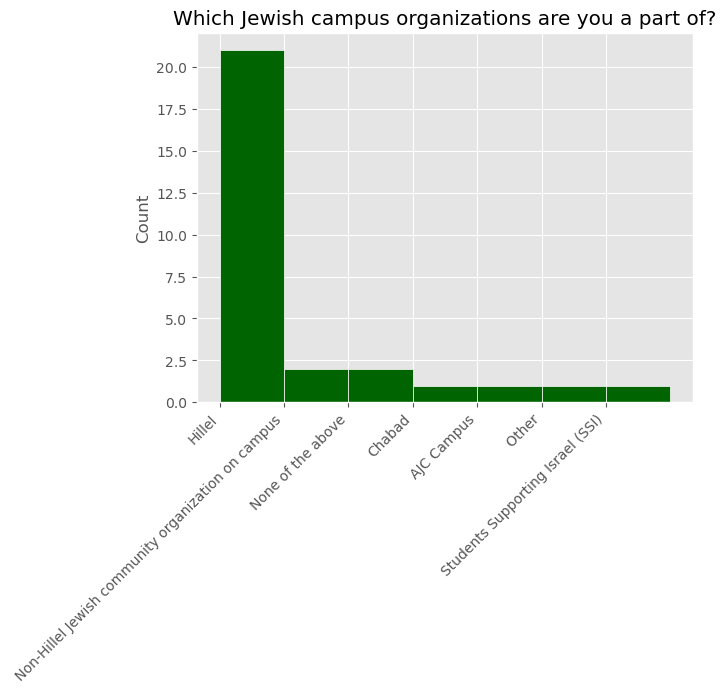

In [233]:
response_series = df_survey['Which Jewish campus organizations are you a part of? (Select all that apply)']

plt.hist(response_series,
         bins=np.arange(len(response_series.unique()) + 1), 
         edgecolor='white',
         color='darkgreen'
         )
plt.ylim=(0, 25), 
plt.yticks=np.arange(0, 20, 2)
plt.xticks(np.arange(len(response_series.unique())), response_series.unique(), rotation=45, ha='right')

      

      

  
      
#ax.set_xticks(x) # Show major ticks
#ax.set_xticklabels([]) 
#plt.xlabel('Organizations')
#ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.ylabel('Count')
plt.title('Which Jewish campus organizations are you a part of?')
plt.show()